In [50]:
# Project ini bertujuan mengklasifikasikan kualitas air 
# menjadi dua kategori: Good dan Not Good 
# berdasarkan parameter seperti pH, DO, dan turbidity. 
# Karena dataset tidak memiliki label kualitas air asli, 
# label dibuat menggunakan aturan sederhana, 
# lalu digunakan untuk melatih model machine learning sebagai baseline.
# Project ini menggunakan Python dengan pustaka seperti pandas,
# scikit-learn, dan matplotlib.

# tujuan dibuatnya project ini juga sebagai latihan dalam
# menerapkan teknik machine learning dasar pada dataset


In [51]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [52]:
df = pd.read_csv('Water Quality Testing.csv')
print(df.head())
df.head()                       

   Sample ID    pH  Temperature (°C)  Turbidity (NTU)  \
0          1  7.25              23.1              4.5   
1          2  7.11              22.3              5.1   
2          3  7.03              21.5              3.9   
3          4  7.38              22.9              3.2   
4          5  7.45              20.7              3.8   

   Dissolved Oxygen (mg/L)  Conductivity (µS/cm)  
0                      7.8                   342  
1                      6.2                   335  
2                      8.3                   356  
3                      9.5                   327  
4                      8.1                   352  


,Sample ID,pH,Temperature (°C),Turbidity (NTU),Dissolved Oxygen (mg/L),Conductivity (µS/cm)
0,1,7.25,23.1,4.5,7.8,342
1,2,7.11,22.3,5.1,6.2,335
2,3,7.03,21.5,3.9,8.3,356
3,4,7.38,22.9,3.2,9.5,327
4,5,7.45,20.7,3.8,8.1,352


In [53]:
# dataset diambil dari Kaggle:
# https://www.kaggle.com/datasets/shreyanshverma27/water-quality-testing/data
# diakses pada 04 Februari 2025
# dataset memiliki 500 baris dan 6 kolom:
# Sample ID, pH, Do, Turbidity, Conductivity, dan Temperature

desc_df = pd.DataFrame([{
    'Project': 'Water Quality Classification',
    'Description': 'Classifying water quality into Good and Not Good based on parameters like pH, DO, and turbidity using machine learning techniques.',
    'Dataset Source': 'Kaggle - Water Quality Testing',
    'Date Accessed': '04 February 2025',
    'Technologies Used': 'Python, pandas, scikit-learn, matplotlib'
}])

display(desc_df)

,Project,Description,Dataset Source,Date Accessed,Technologies Used
0,Water Quality Classification,Classifying water quality into Good and Not Go...,Kaggle - Water Quality Testing,04 February 2025,"Python, pandas, scikit-learn, matplotlib"


In [54]:
df.info()
df.describe()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Sample ID                500 non-null    int64  
 1   pH                       500 non-null    float64
 2   Temperature (°C)         500 non-null    float64
 3   Turbidity (NTU)          500 non-null    float64
 4   Dissolved Oxygen (mg/L)  500 non-null    float64
 5   Conductivity (µS/cm)     500 non-null    int64  
dtypes: float64(4), int64(2)
memory usage: 23.6 KB


Sample ID                  0
pH                         0
Temperature (°C)           0
Turbidity (NTU)            0
Dissolved Oxygen (mg/L)    0
Conductivity (µS/cm)       0
dtype: int64

In [55]:
# delete duplicate
df.drop_duplicates(inplace=True)
df.duplicated().sum() 

# rename and delete columns
df.drop(columns=['Sample ID'], inplace=True, errors='ignore')
pd.set_option('display.max_columns', None)
df.columns = df.columns.str.strip()
df = df.rename(columns={
    "Temperature (°C)": "Temperature",
    "Turbidity (NTU)": "Turbidity",
    "Dissolved Oxygen (mg/L)": "DO",
    "Conductivity (µS/cm)": "Conductivity"
})

# missing value
missing = df.isna().sum()
print(missing[missing > 0 ]) # menampilkan kolom dengan missing value

Series([], dtype: int64)


In [56]:
numeric_cols = df.select_dtypes(include=np.number).columns
print("Kolom numerik:", list(numeric_cols))

Kolom numerik: ['pH', 'Temperature', 'Turbidity', 'DO', 'Conductivity']


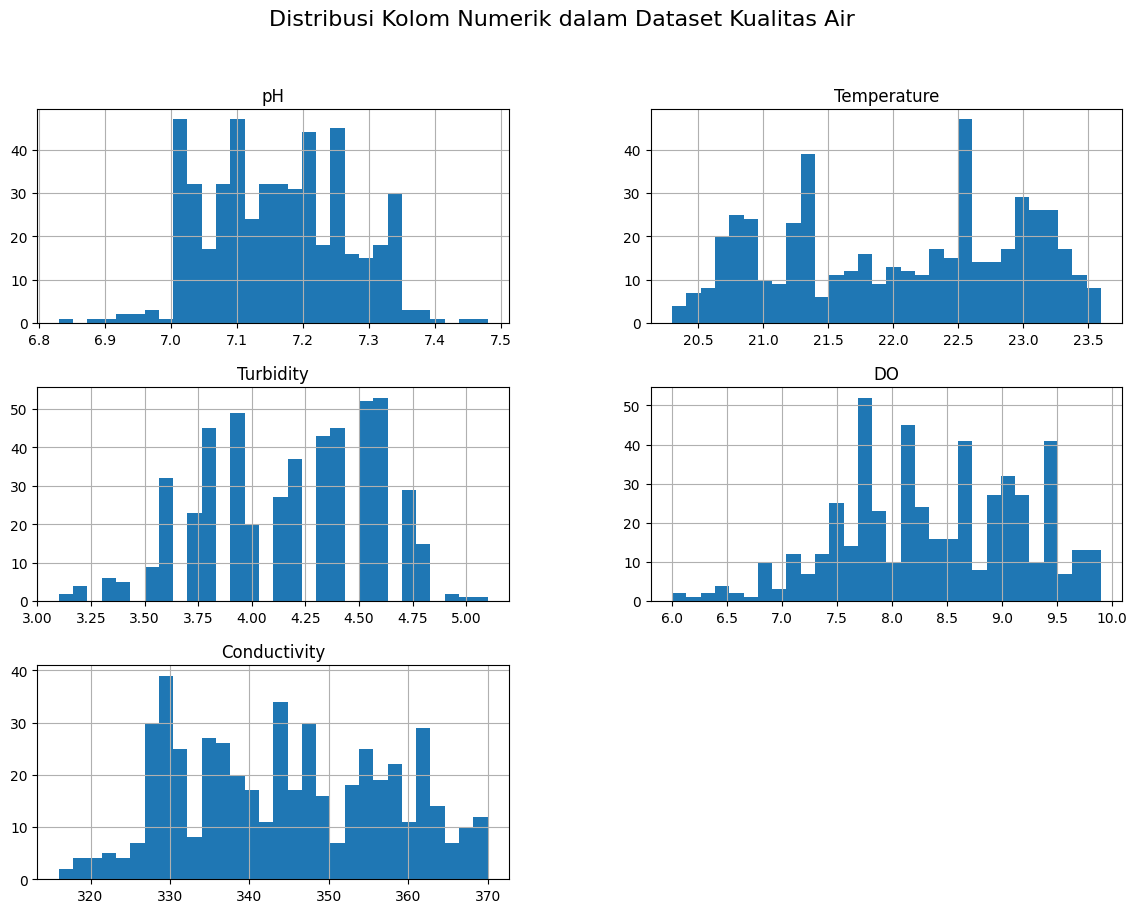

In [57]:
df.hist(bins=30, figsize=(14, 10))
plt.suptitle("Distribusi Kolom Numerik dalam Dataset Kualitas Air", fontsize=16)
plt.show()

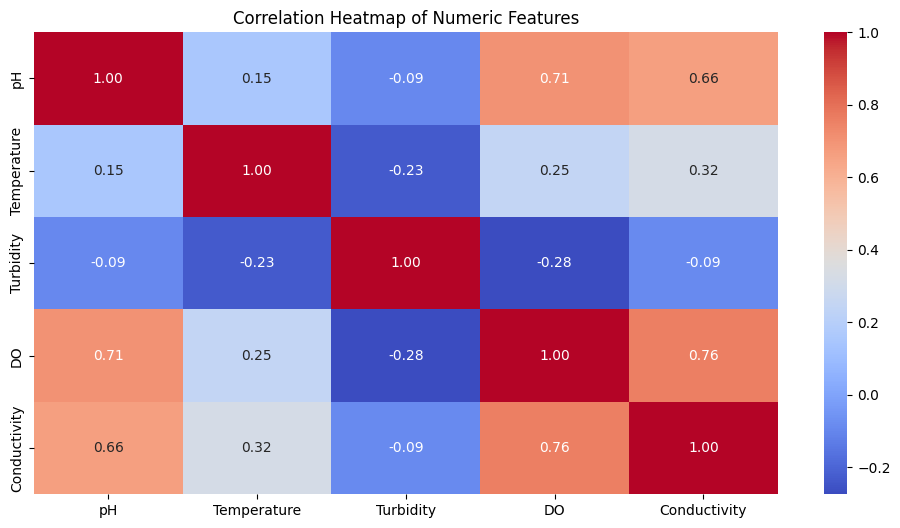

In [58]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

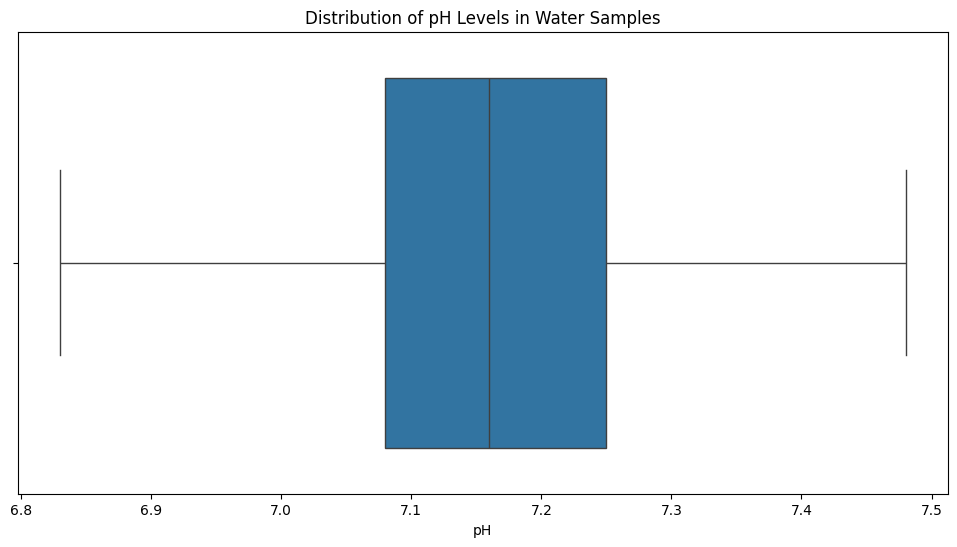

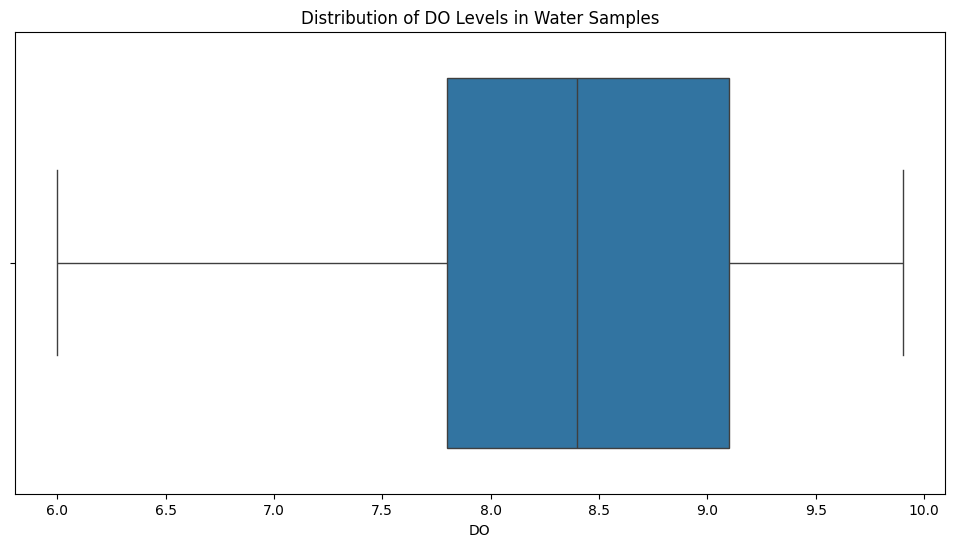

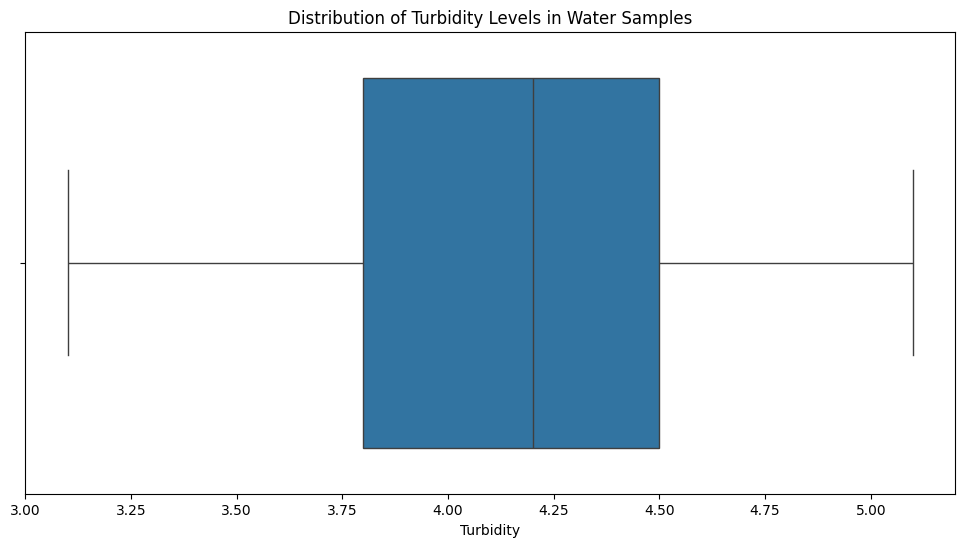

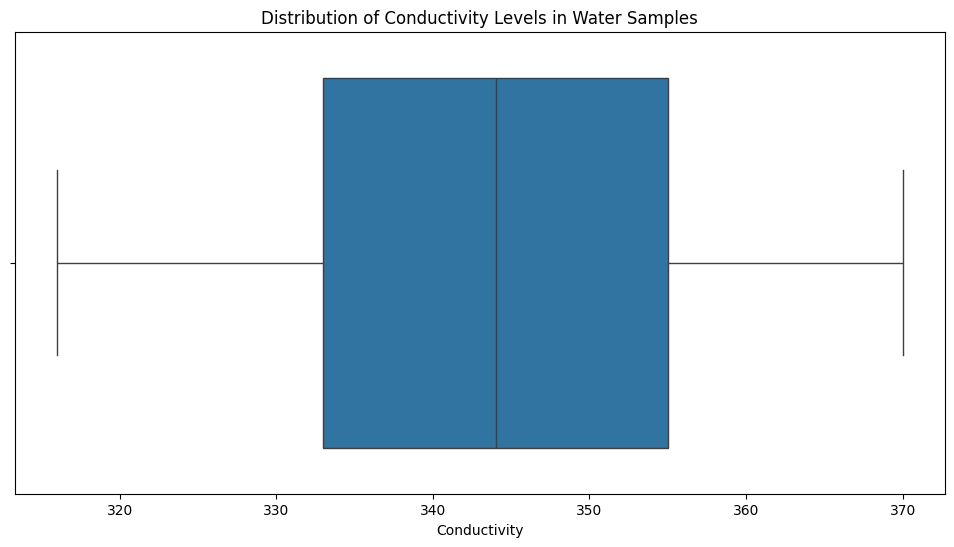

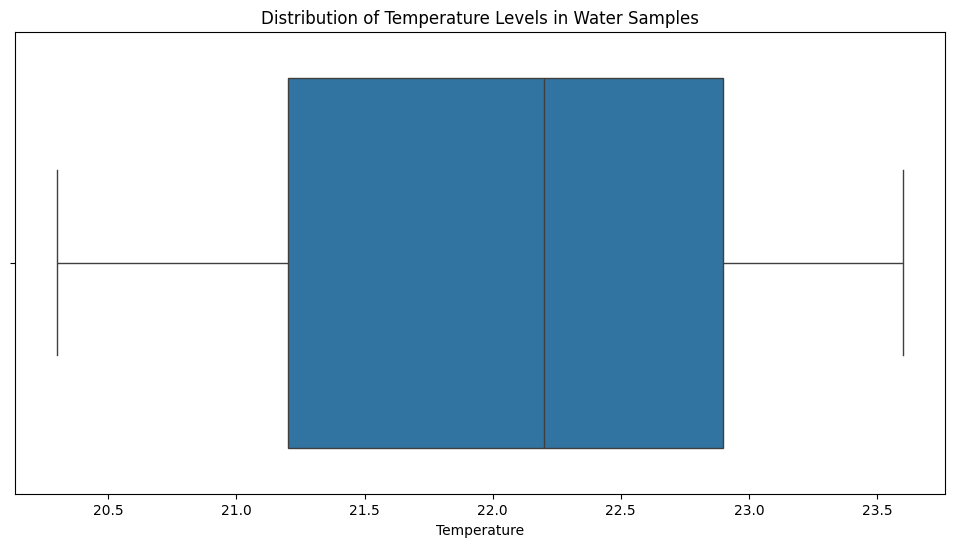

In [59]:
cols = ['pH', 'DO', 'Turbidity', 'Conductivity', 'Temperature']

for col in cols:
    plt.figure(figsize=(12, 6))
    sns.boxplot(x=df[col])
    plt.title(f"Distribution of {col} Levels in Water Samples")
    plt.show()


In [60]:
# labeling

df["water_quality"] = (
    (df["pH"].between(6.5, 8.5)) &
    (df["DO"] >= 6) &
    (df["Turbidity"] <= 4) &
    (df["Conductivity"] <= 400)
).astype(int)

In [61]:
cond_ph = df["pH"].between(6.5, 8.5)
cond_do = df["DO"] >= 6
cond_turb = df["Turbidity"] <= 4
cond_conduct = df["Conductivity"] <= 400

print("pH:", cond_ph.value_counts())
print("DO:", cond_do.value_counts())
print("Turbidity:", cond_turb.value_counts())
print("Conductivity:", cond_conduct.value_counts())

bad_rows = df[~(cond_ph & cond_do & cond_turb)]
bad_rows


pH: pH
True    500
Name: count, dtype: int64
DO: DO
True    500
Name: count, dtype: int64
Turbidity: Turbidity
False    305
True     195
Name: count, dtype: int64
Conductivity: Conductivity
True    500
Name: count, dtype: int64


,pH,Temperature,Turbidity,DO,Conductivity,water_quality
0,7.25,23.1,4.5,7.8,342,0
1,7.11,22.3,5.1,6.2,335,0
5,6.89,23.6,4.6,7.2,320,0
6,7.19,21.2,4.2,8.8,350,0
8,7.31,20.4,4.1,8.4,360,0
...,...,...,...,...,...,...
493,7.19,21.4,4.3,7.8,336,0
494,7.11,22.7,4.5,8.3,347,0
495,7.01,20.8,4.6,7.1,327,0
497,7.02,21.2,4.7,7.5,334,0


In [62]:
# cek distribusi label
df["water_quality"].value_counts()

water_quality
0    305
1    195
Name: count, dtype: int64

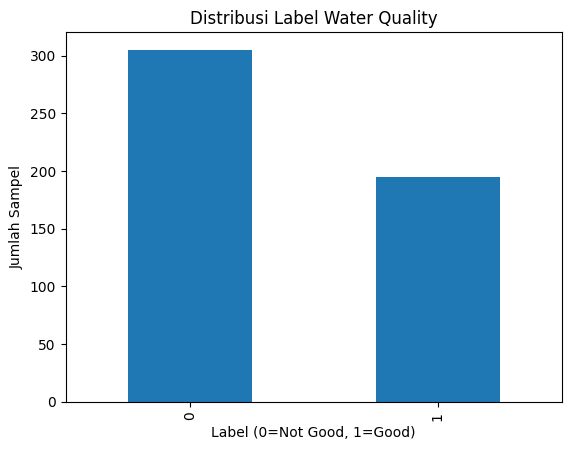

In [63]:
df["water_quality"].value_counts().plot(kind="bar")
plt.title("Distribusi Label Water Quality")
plt.xlabel("Label (0=Not Good, 1=Good)")
plt.ylabel("Jumlah Sampel")
plt.show()

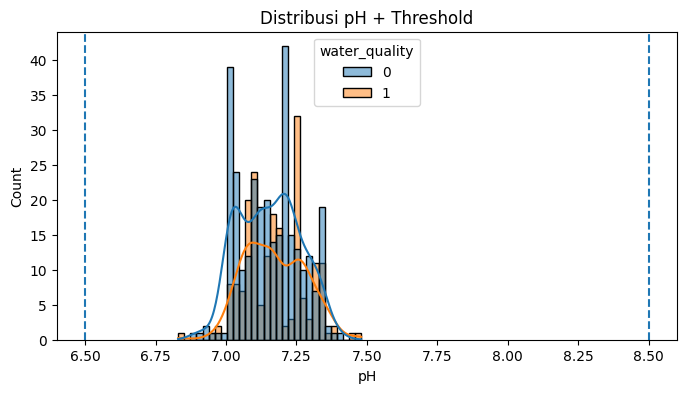

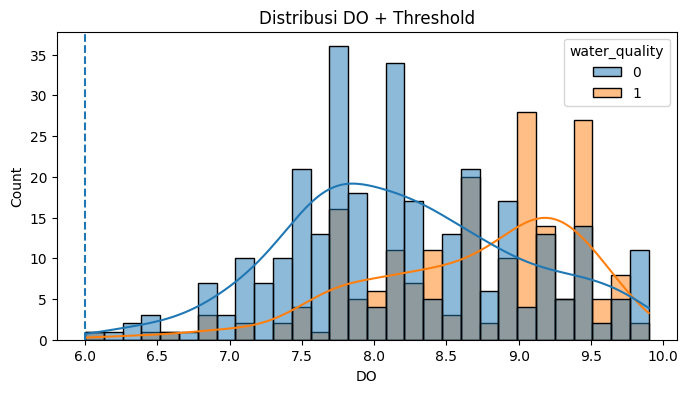

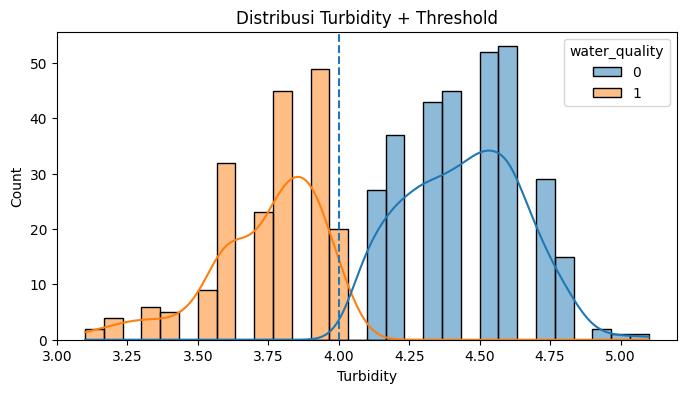

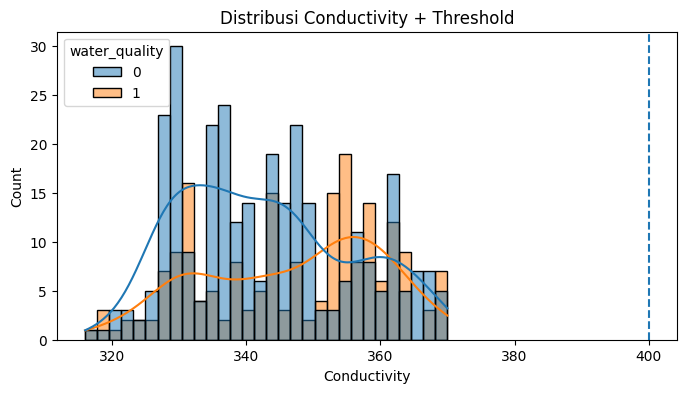

In [64]:
rules = {
    "pH": [("min", 6.5), ("max", 8.5)],
    "DO": [("min", 6.0)],
    "Turbidity": [("max", 4.0)],
    "Conductivity": [("max", 400.0)]
}
for col, thresholds in rules.items():
    plt.figure(figsize=(8,4))
    sns.histplot(data=df, x=col, hue="water_quality", bins=30, kde=True)
    
    # garis threshold
    for t in thresholds:
        plt.axvline(t[1], linestyle="--")
    plt.title(f"Distribusi {col} + Threshold")
    plt.show()

In [65]:
features = ["pH", "DO", "Turbidity", "Conductivity"]
X = df[features]
y = df["water_quality"]


In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [67]:
logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

logreg.fit(X_train, y_train)
pred_logreg = logreg.predict(X_test)

print("Logistic Regression")
print(classification_report(y_test, pred_logreg))


Logistic Regression
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        61
           1       1.00      0.97      0.99        39

    accuracy                           0.99       100
   macro avg       0.99      0.99      0.99       100
weighted avg       0.99      0.99      0.99       100



In [68]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

print("Random Forest")
print(classification_report(y_test, pred_rf))


Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        61
           1       1.00      1.00      1.00        39

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



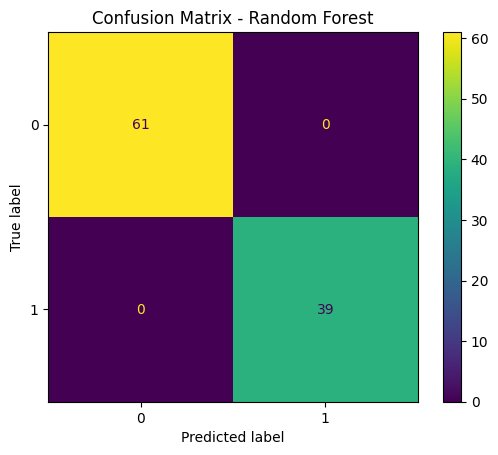

In [69]:
cm = confusion_matrix(y_test, pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()


In [70]:
scores = cross_val_score(rf, X, y, cv=5, scoring="f1")
print("CV F1 scores:", scores)
print("Mean F1:", scores.mean())


CV F1 scores: [1. 1. 1. 1. 1.]
Mean F1: 1.0


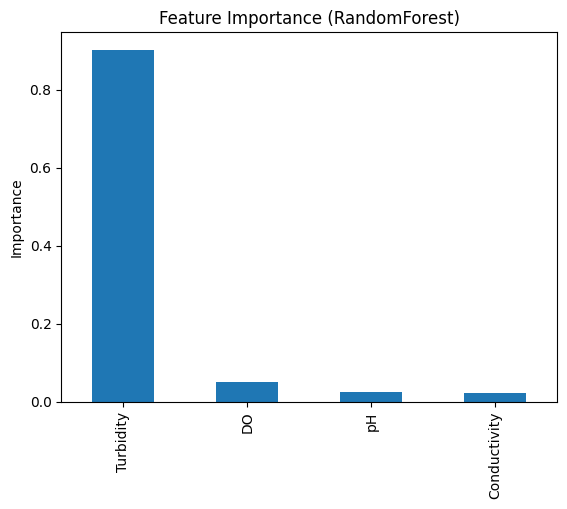

In [71]:
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

importances.plot(kind="bar")
plt.title("Feature Importance (RandomForest)")
plt.ylabel("Importance")
plt.show()


In [72]:
## Conclusion

# Pada project ini dilakukan klasifikasi kualitas air menggunakan dataset
# Water Quality Testing dari Kaggle dengan dua model machine learning, 
# yaitu Logistic Regression dan Random Forest. Project ini mengelompokkan
# kategori air ke dua bagian< yaitu "good""Water Quality Testing.csv"

#Berdasarkan hasil evaluasi menggunakan classification report, 
# Random Forest memiliki performa yang lebih baik dibandingkan Logistic Regression
# dalam memprediksi kelas kualitas air. Karena Random Forest menunjukkan nilai precision, recall,
# dan F1-score yang lebih tinggi pada kedua kelas, terutama pada kelas minoritas (Not Good).
# Namun, model masih memiliki keterbatasan karena dataset relatif terbatas dan belum dilakukan 
# tuning hyperparameter secara mendalam. Selain itu, distribusi kelas yang tidak seimbang dapat memengaruhi performa model.

# Fitur yang paling berpengaruh terhadap prediksi berdasarkan model Random Forest adalah 
# pH, Turbidity, dan Dissolved Oxygen, yang memang merupakan indikator penting dalam penilaian kualitas air.
# Namun, saya menambahkan conductivity agar model memiliki informasi lebih lengkap.


# Selain itu, model masih memiliki keterbatasan karena dataset relatif 
# terbatas. Dataset tidak memiliki ground truth kualitas air asli,
# sehingga label dibuat berdasarkan aturan sederhana yang mungkin 
# tidak mencerminkan kondisi sebenarnya secara akurat.

# Untuk pengembangan selanjutnya, dapat dilakukan:
# - dataset yang lebih besar dan beragam
# - eksplorasi teknik feature engineering yang lebih mendalam
# - tuning hyperparameter model untuk meningkatkan performa
# - eksplorasi model machine learning lainnya seperti Gradient Boosting atau SVM


